# What are the most demanded skills for the top 3 most popular data roles?
Focusing on Data Analyst, Data Scientist, and Data Engineer roles in Australia.

#### Methodology
1. Clean-up skill column
2. Calculate skill count based on `job_title_short`
3. Calculate skill percentage
4. Plot final findings



## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter Data for Target Roles and Countries

Filter the data for Data Analysts, Data Scientists, and Data Engineers in Australia.

In [2]:
# Filter for Data Analyst, Data Scientist, Data Engineer in Australia
countries = ['Australia']
roles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[
    (df['job_country'].isin(countries)) &
    (df['job_title_short'].isin(roles))
].copy()


## Explode Skills

Converts the `job_skills` column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the `job_title` and `job_skills` columns, allowing us to analyze the distribution of skills across different data job titles.

In [3]:
df_skills = df_filtered.explode('job_skills')

df_skills[['job_title', 'job_skills']]

,job_title,job_skills
90,Data Scientist,python
90,Data Scientist,sql
90,Data Scientist,r
90,Data Scientist,java
90,Data Scientist,bash
...,...,...
785377,Data Engineer,airflow
785377,Data Engineer,docker
785377,Data Engineer,kubernetes
785430,Azure Data Engineer,azure


## Count Skills per Job Title

Groups DataFrame by `job_skills` and `job_title_short`, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, `df_skills_count`, shows the frequency of each skill with each job title.

In [4]:
# Group by job_skills and job_title_short and count the number of occurrences
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
368,sql,Data Engineer,2914
290,python,Data Engineer,2388
28,azure,Data Engineer,1789
25,aws,Data Engineer,1752
354,spark,Data Engineer,1157
...,...,...,...
214,ms access,Data Scientist,1
220,neo4j,Data Analyst,1
222,neo4j,Data Scientist,1
223,next.js,Data Engineer,1


## Create List of Top 3 Roles

#### Focus: Data Analysts, Data Engineers, and Data Scientists

Filter the job titles based on the most popular.

In [5]:
# Explicitly define the roles we are interested in
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

## Plot Skill Counts

Creates a stacked horizontal bar chart for the top 5 skills for Top 3 roles, displaying the frequency of each skill. 

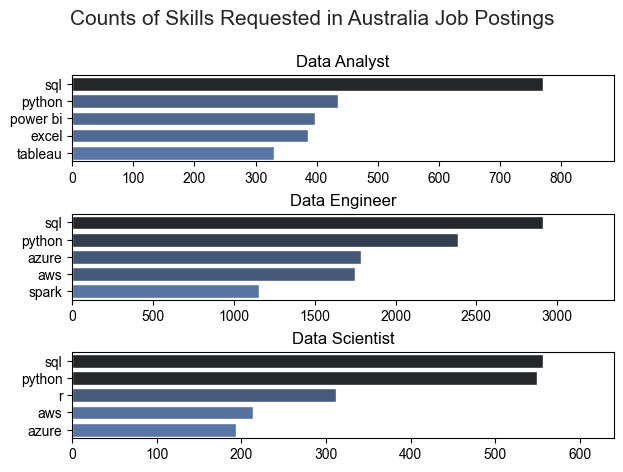

In [6]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, max(df_plot['skill_count'].max() * 1.15, 1))

fig.suptitle('Counts of Skills Requested in Australia Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()


## Convert Counts to Percentages

Counts alone do not show the share of job postings requesting each skill, so we convert them into percentages within each target role.


Before calculating percentages, get the total number of job postings for each target role from the filtered Australia dataset. The resulting DataFrame, `df_job_title_count`, stores each `job_title_short` with its corresponding `jobs_total`.


In [7]:
df_job_title_count = df_filtered['job_title_short'].value_counts().reset_index()
df_job_title_count.columns = ['job_title_short', 'jobs_total']

df_job_title_count


,job_title_short,jobs_total
0,Data Engineer,4658
1,Data Analyst,1658
2,Data Scientist,1179


Then we calculate the percentages. First merge `df_skills_count` and `df_job_title_count`, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column. 

In [8]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,2914,4658,62.559038
1,python,Data Engineer,2388,4658,51.266638
2,azure,Data Engineer,1789,4658,38.407042
3,aws,Data Engineer,1752,4658,37.612709
4,spark,Data Engineer,1157,4658,24.838987
...,...,...,...,...,...
449,ms access,Data Scientist,1,1179,0.084818
450,neo4j,Data Analyst,1,1658,0.060314
451,neo4j,Data Scientist,1,1179,0.084818
452,next.js,Data Engineer,1,4658,0.021468


## Plot Percentage Count

Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

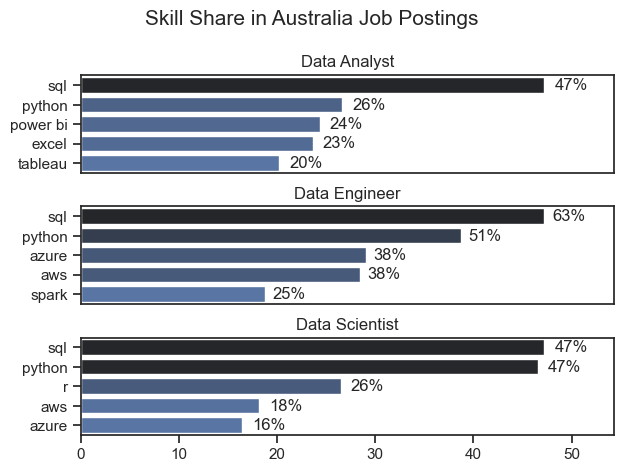

In [9]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, max(df_plot['skill_percent'].max() * 1.15, 1))
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Skill Share in Australia Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()


## Australia Analysis
Visualizing the top skills for the selected data roles in Australia.


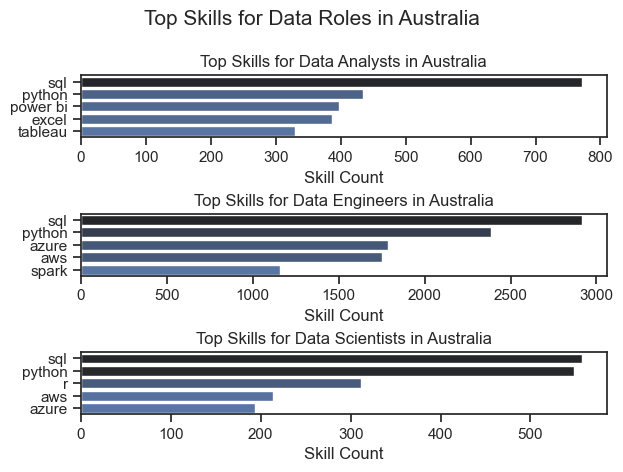

In [10]:
# Group by country, job_title, and skill
df_country_skills = df_skills.groupby(['job_country', 'job_title_short', 'job_skills']).size().reset_index(name='skill_count')

# Sort
df_country_skills.sort_values(by='skill_count', ascending=False, inplace=True)

countries = ['Australia']
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

for country in countries:
    fig, ax = plt.subplots(len(job_titles), 1)
    sns.set_theme(style='ticks')

    for i, job_title in enumerate(job_titles):
        df_plot = df_country_skills[
            (df_country_skills['job_country'] == country) & 
            (df_country_skills['job_title_short'] == job_title)
        ].head(5)

        sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
        ax[i].set_title(f'Top Skills for {job_title}s in {country}')
        ax[i].set_ylabel('')
        ax[i].set_xlabel('Skill Count')
        ax[i].get_legend().remove()

    fig.suptitle(f'Top Skills for Data Roles in {country}', fontsize=15)
    fig.tight_layout(h_pad=0.5)
    plt.show()
